# ATS Resume Matching Fine-Tuning Notebook

This notebook is organized as a teaching workflow, not just a training script.

What you will do:
- load the train and validation CSV files from Google Drive
- inspect the raw ATS dataset and understand the schema
- split the combined `text` field into `resume_text` and `job_description`
- run focused EDA to understand score balance, text length, and keyword patterns
- benchmark several embedding backbones
- fine-tune the best model for resume-job similarity scoring
- validate the trained model with metrics, figures, and manual test cases

Main idea:
A resume-matching model should compare two texts as a pair. If one row looks like `resume text SEP job description`, we split it into two inputs before training.

Expected output:
By the end, you will have a saved fine-tuned model, evaluation plots, and a reusable inference function.

In [ ]:
# Step 1: import the libraries used for data work and visualization
# `display` gives cleaner tables in Colab, and `CountVectorizer` helps explain label-specific keywords later.
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid')

In [ ]:
# Step 2: mount Google Drive so Colab can read your dataset files and save trained models
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 3: load the provided train and validation splits from Google Drive
# Example path: /content/drive/MyDrive/Datasets/Resume_dataset/ATS_scoring_resume_dataset/train.csv
train_data = pd.read_csv('/content/drive/MyDrive/Datasets/Resume_dataset/ATS_scoring_resume_dataset/train.csv')
val_data = pd.read_csv('/content/drive/MyDrive/Datasets/Resume_dataset/ATS_scoring_resume_dataset/validation.csv')

print(f'Train shape: {train_data.shape}')
print(f'Validation shape: {val_data.shape}')

## Dataset Audit

The next few cells answer three questions before modeling:
- what columns do we have?
- is the target score balanced enough to learn from?
- does the raw `text` field really contain two pieces separated by `SEP`?

This check matters because a model can fail for simple data reasons such as missing values, duplicate rows, or a broken split format.

In [ ]:
# Step 4: preview a few important columns from both splits
preview_cols = [col for col in ['text', 'ats_score', 'original_label'] if col in train_data.columns]

print('Train preview')
display(train_data[preview_cols].head(2))
print('Validation preview')
display(val_data[preview_cols].head(2))

,text,ats_score,original_label
0,SummaryFinancial Accountant specializing in fi...,27.6,No Fit
1,SummaryExperienced Data Analyst who responds t...,57.6,Potential Fit
2,SummaryDigital marketing professional experien...,22.4,No Fit
3,Professional SummaryHighly motivated Sales Ass...,28.0,No Fit
4,Professional SummaryCurrently working with Cat...,58.3,Potential Fit
5,Professional SummaryAccountant with more than ...,87.7,Good Fit
6,ProfileExperienced Corporate and Software Prof...,28.6,No Fit
7,SummaryHaving achieved a milestone of 7 years ...,22.7,No Fit
8,SummaryTo obtain a position where my business ...,52.2,Potential Fit
9,SummarySeasoned Data Entry Operator with 5 yea...,24.6,No Fit


In [ ]:
# Step 5: compare the size of the train and validation splits
overview = pd.DataFrame(
    {
        'rows': [len(train_data), len(val_data)],
        'columns': [train_data.shape[1], val_data.shape[1]],
    },
    index=['train', 'validation']
)
display(overview)

(1275, 3)

In [ ]:
# Step 6: inspect data types and missing values to catch data quality problems early
schema_df = pd.DataFrame({
    'dtype': train_data.dtypes.astype(str),
    'train_nulls': train_data.isnull().sum(),
    'validation_nulls': val_data.isnull().sum().reindex(train_data.columns, fill_value=0),
})
display(schema_df.sort_values(['train_nulls', 'validation_nulls'], ascending=False))

,ats_score
count,5099.000000
mean,47.187452
std,24.970249
min,19.160000
25%,24.700000
50%,29.900000
75%,59.800000
max,90.050000


In [ ]:
# Step 7: summarize the numeric target so we know the score range the model must learn
score_col = 'ats_score' if 'ats_score' in train_data.columns else 'match_score'

target_summary = pd.DataFrame({
    'train': train_data[score_col].describe(),
    'validation': val_data[score_col].describe(),
})
display(target_summary)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5099 entries, 0 to 5098
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   text            5099 non-null   object 
 1   ats_score       5099 non-null   float64
 2   original_label  5099 non-null   object 
dtypes: float64(1), object(2)
memory usage: 119.6+ KB


In [ ]:
# Step 8: compare label balance across train and validation
label_col = 'original_label' if 'original_label' in train_data.columns else 'match_label'

label_summary = pd.concat(
    [
        train_data[label_col].value_counts(dropna=False).rename('train_count'),
        val_data[label_col].value_counts(dropna=False).rename('validation_count'),
    ],
    axis=1,
).fillna(0).astype(int)

display(label_summary)

,text,original_label
count,5099,5099
unique,5099,3
top,Career OverviewMeticulous Senior Software Test...,No Fit
freq,1,2565


In [ ]:
# Step 9: check for duplicate rows because duplicates can make evaluation look better than it really is
duplicate_summary = pd.DataFrame({
    'dataset': ['train', 'validation'],
    'duplicate_rows': [int(train_data.duplicated().sum()), int(val_data.duplicated().sum())],
})
display(duplicate_summary)

,0
text,0
ats_score,0
original_label,0


In [ ]:
# Step 10: inspect one raw row to understand the original text format
sample_text = str(train_data['text'].iloc[0])
print(sample_text[:1200])

np.int64(0)

In [ ]:
# Step 11: verify that the separator token is present in most rows
train_sep_ratio = train_data['text'].astype(str).str.contains(r'\bSEP\b', regex=True).mean()
val_sep_ratio = val_data['text'].astype(str).str.contains(r'\bSEP\b', regex=True).mean()

print(f'Train rows containing SEP: {train_sep_ratio:.2%}')
print(f'Validation rows containing SEP: {val_sep_ratio:.2%}')

array(['Good Fit', 'No Fit', 'Potential Fit'], dtype=object)

## Split The Combined Text Into Resume And Job Description

What this stage does:
- reads the raw `text` column
- finds the `SEP` token
- creates two model inputs: `resume_text` and `job_description`

Why this matters:
A semantic matching model should compare a candidate profile with a job requirement as two separate texts.

Example:
`Python developer with Django experience SEP Hiring a backend engineer with Django and REST API skills`
becomes:
- `resume_text = Python developer with Django experience`
- `job_description = Hiring a backend engineer with Django and REST API skills`

This pair format is much better for ATS similarity training than treating the full row as one block of text.

In [ ]:
# Step 12: show the text around the separator so the split logic is easy to understand
sample_text = str(train_data['text'].iloc[0])
sep_match = re.search(r'\bSEP\b', sample_text)

if sep_match:
    start = max(0, sep_match.start() - 250)
    end = min(len(sample_text), sep_match.end() + 250)
    print(sample_text[start:end])
else:
    print('SEP not found in the first training example.')

SummaryI am seeking a position wherein I may use my proven development, technical, and analytical skills while having the opportunity to continue my learning and diversify my experiences. Highlights17 years experience in Information TechnologyHeld a Secret security clearanceExpert in business process including requirements gathering, analysis, design, development, testing and implementation of software applicationsStrong understanding of structured programming techniques and Software Development life Cycle (SDLC) - Agile (SCRUM)Able to learn, understand, and apply new software programs easily.Interface design and implementationAgile development methodologiesProject management and Requirements analysis and design phasesProcess improvementResults-orientedStaff developmentExcellent communication, analytical, interpersonal, and presentation skillsExpert ability at managing multiple projects simultaneously Experience06 2011to11 2015Manager of Software DevelopmentAvidxchange Birmingham,AL,SA

In [ ]:
# Step 13: split the combined text field into two separate modeling inputs
split_pattern = r'(?i)\s*\bSEP\b\s*'

for frame_name, frame in [('train', train_data), ('validation', val_data)]:
    frame[['resume_text', 'job_description']] = (
        frame['text']
        .astype('string')
        .str.split(split_pattern, n=1, expand=True)
    )
    frame['resume_text'] = frame['resume_text'].astype('string').str.strip()
    frame['job_description'] = frame['job_description'].astype('string').str.strip()
    print(f'{frame_name}: created resume_text and job_description columns')

In [ ]:
# Step 14: inspect one example after splitting so we can verify both sides look correct
print('Resume sample:')
print(train_data['resume_text'].iloc[0][:600])
print('\n' + '-' * 80 + '\n')
print('Job description sample:')
print(train_data['job_description'].iloc[0][:600])

SummaryI am seeking a position wherein I may use my proven development, technical, and analytical skills while having the opportunity to continue my learning and diversify my experiences. Highlights17 years experience in Information TechnologyHeld a Secret security clearanceExpert in business proces
--------------------------------------------------
- Share resume to shan imrsoft.com Job Title JDE Business AnalystLocation REMOTE Mandatory Skills JDE World Homebuilder Job Description Extensive experience ( 10 years) in JDE World Homebuilder, Job Cost, and Procurement module functions functionality and associated business processes. (Primary)Hands on Experience in World and E1 will be added advantage.Experience working in migration of JDE World to EnterpriseOne.Experience in data preparation, conversion and validation World to E1 migration.Works effectively in a collaborative environment with project team peers, leadership and vendors.


In [ ]:
# Step 15: remove boilerplate job-post prefixes that do not help semantic matching
noise_pattern = r'^-?\s*Share resume to.*?Job Title'

for frame in [train_data, val_data]:
    frame['job_description'] = (
        frame['job_description']
        .str.replace(noise_pattern, 'Job Title', regex=True)
        .str.strip()
    )

In [ ]:
# Step 16: validate the split result with null and empty-string checks
quality_checks = pd.DataFrame({
    'dataset': ['train', 'validation'],
    'rows': [len(train_data), len(val_data)],
    'resume_nulls': [int(train_data['resume_text'].isna().sum()), int(val_data['resume_text'].isna().sum())],
    'jd_nulls': [int(train_data['job_description'].isna().sum()), int(val_data['job_description'].isna().sum())],
    'empty_resume': [int(train_data['resume_text'].fillna('').eq('').sum()), int(val_data['resume_text'].fillna('').eq('').sum())],
    'empty_jd': [int(train_data['job_description'].fillna('').eq('').sum()), int(val_data['job_description'].fillna('').eq('').sum())],
})
display(quality_checks)

Total rows: 5099
Resume nulls: 0
JD nulls: 0
Total rows: 1275
Resume nulls: 0
JD nulls: 0


In [ ]:
# Step 17: preview the cleaned pair that will later be used for modeling
preview_cols = ['resume_text', 'job_description', 'ats_score', 'original_label']
display(train_data[preview_cols].head(3))

SummaryI am seeking a position wherein I may use my proven development, technical, and analytical skills while having the opportunity to continue my learning and diversify my experiences. Highlights17 years experience in Information TechnologyHeld a Secret security clearanceExpert in business proces
--------------------------------------------------
Job Title JDE Business AnalystLocation REMOTE Mandatory Skills JDE World Homebuilder Job Description Extensive experience ( 10 years) in JDE World Homebuilder, Job Cost, and Procurement module functions functionality and associated business processes. (Primary)Hands on Experience in World and E1 wil


## Focused EDA For ATS Matching

The next figures are designed to answer practical modeling questions:
- is the score distribution balanced or skewed?
- how separated are the labels by score?
- are resumes and job descriptions similar in length?
- do text length patterns affect score?
- what words appear most often in each label bucket?

This is better than many small debug cells because each figure now supports a modeling decision.

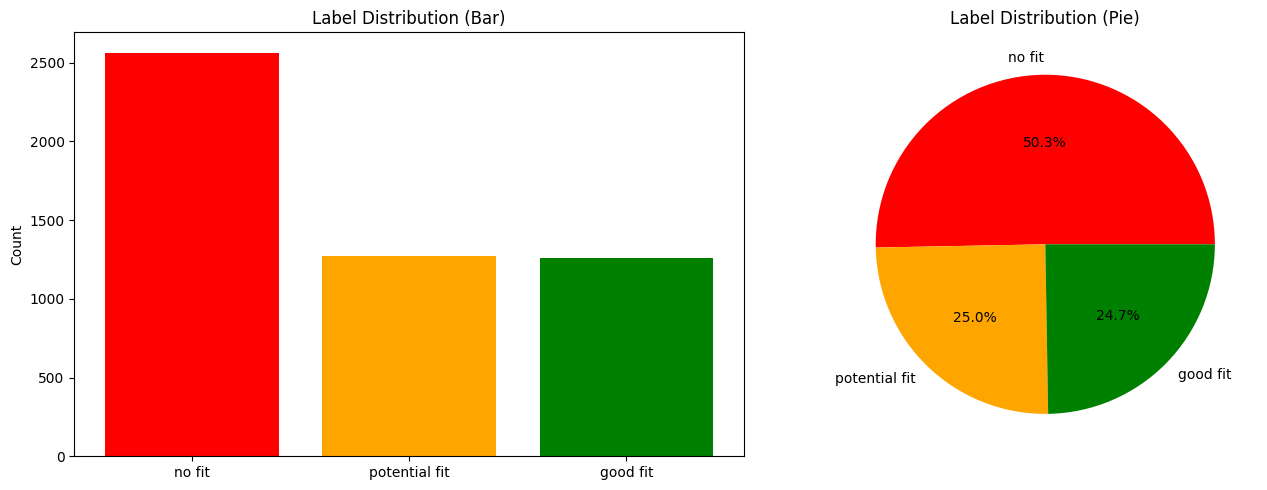

In [ ]:
# Step 18: build one combined dataframe for EDA and create helper features used in the figures
eda_df = pd.concat([train_data.copy(), val_data.copy()], ignore_index=True)
eda_df['match_score'] = pd.to_numeric(eda_df['ats_score'], errors='coerce').clip(0, 100) / 100
eda_df['match_label'] = np.select(
    [
        eda_df['match_score'] < 0.40,
        eda_df['match_score'].between(0.40, 0.70, inclusive='both'),
        eda_df['match_score'] > 0.70,
    ],
    ['low', 'medium', 'high'],
    default='unknown'
)
eda_df['resume_len'] = eda_df['resume_text'].astype(str).str.split().str.len()
eda_df['jd_len'] = eda_df['job_description'].astype(str).str.split().str.len()
eda_df = eda_df.dropna(subset=['match_score', 'resume_text', 'job_description']).copy()

print(f'EDA rows: {len(eda_df):,}')
display(eda_df[['match_score', 'match_label', 'original_label', 'resume_len', 'jd_len']].head())

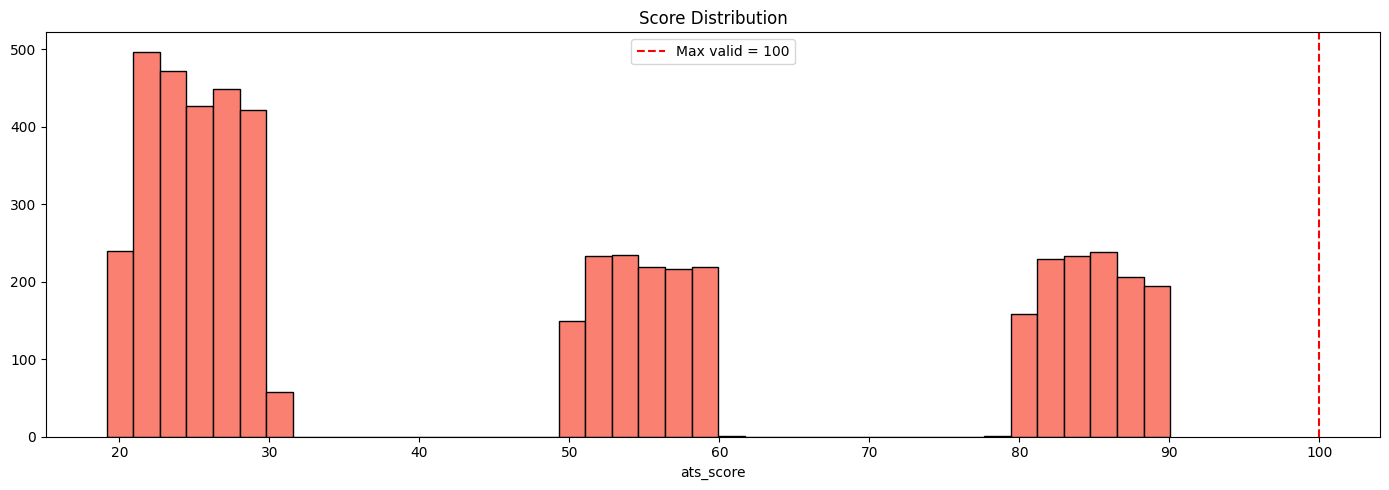

In [ ]:
# Step 19: visualize class balance and score distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
palette = {'low': '#d1495b', 'medium': '#edae49', 'high': '#2a9d8f'}
order = ['low', 'medium', 'high']

sns.countplot(data=eda_df, x='match_label', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Label Balance')
axes[0].set_xlabel('Match Label')
axes[0].set_ylabel('Rows')

sns.histplot(data=eda_df, x='match_score', hue='match_label', hue_order=order, bins=30,
             multiple='stack', palette=palette, ax=axes[1])
axes[1].set_title('Match Score Distribution')
axes[1].set_xlabel('Normalized Score (0 to 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_579/2131582793.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_plot, x='original_label', y='ats_score',


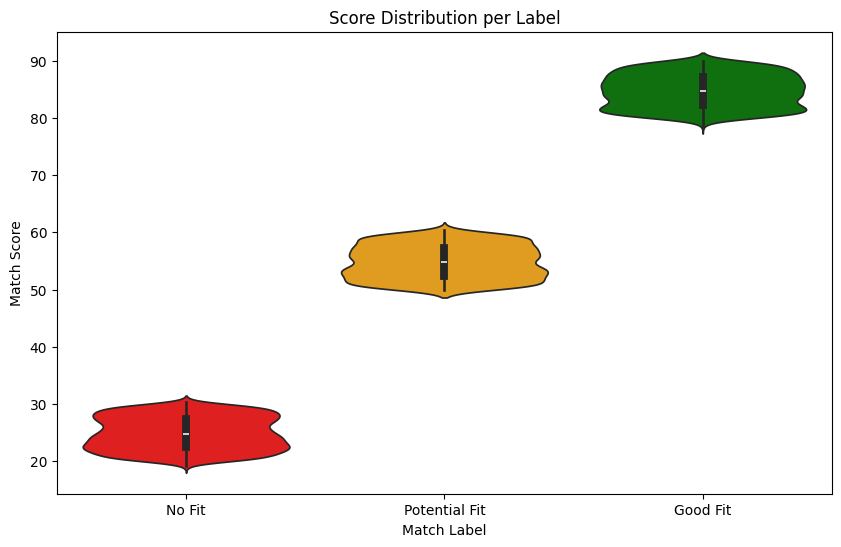

In [ ]:
# Step 20: check whether the labels are clearly separated by score
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=eda_df,
    x='match_label',
    y='match_score',
    order=['low', 'medium', 'high'],
    palette=['#d1495b', '#edae49', '#2a9d8f'],
    inner='quartile'
)
plt.title('Score Distribution By Match Label')
plt.xlabel('Match Label')
plt.ylabel('Normalized Score')
plt.ylim(0, 1)
plt.show()

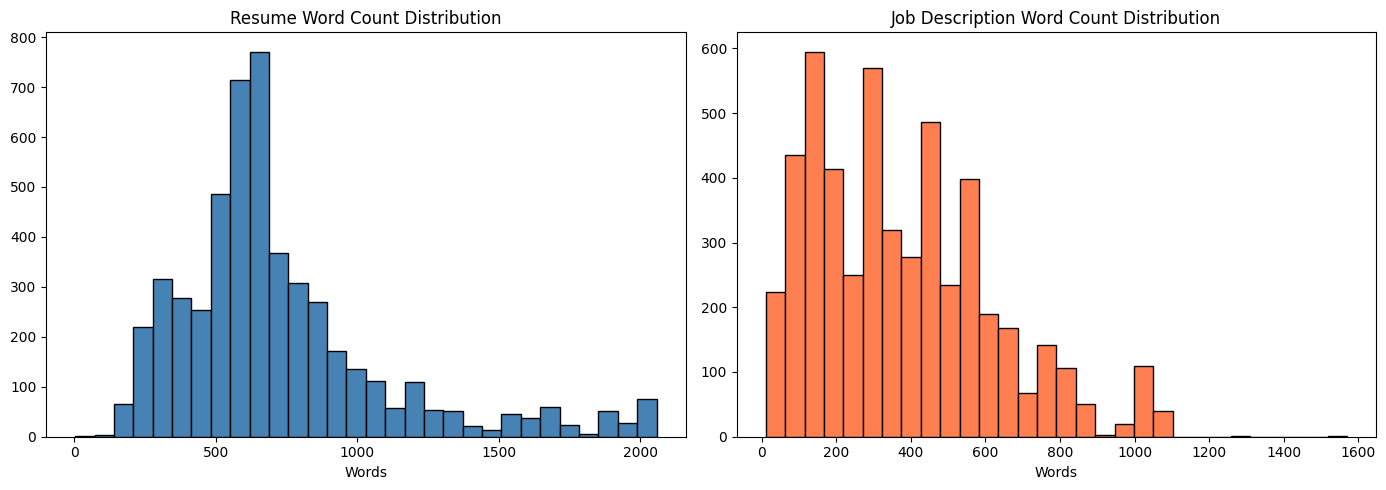

In [ ]:
# Step 21: compare text length distributions for resumes and job descriptions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(eda_df['resume_len'], bins=35, color='#457b9d', edgecolor='white', ax=axes[0])
axes[0].set_title('Resume Length Distribution')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Count')

sns.histplot(eda_df['jd_len'], bins=35, color='#e76f51', edgecolor='white', ax=axes[1])
axes[1].set_title('Job Description Length Distribution')
axes[1].set_xlabel('Job Description Word Count')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

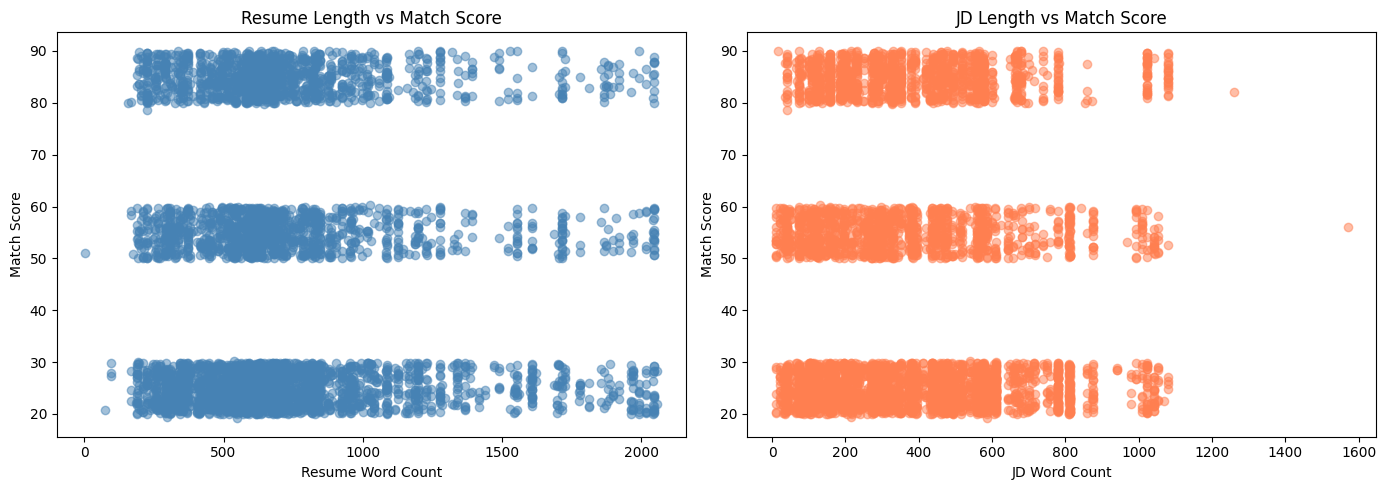

Resume length correlation: -0.006
JD length correlation:     0.021


In [ ]:
# Step 22: test whether text length alone explains the ATS score
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(data=eda_df, x='resume_len', y='match_score', hue='match_label',
                hue_order=['low', 'medium', 'high'], palette=['#d1495b', '#edae49', '#2a9d8f'],
                alpha=0.5, ax=axes[0])
axes[0].set_title('Resume Length vs Match Score')
axes[0].set_xlabel('Resume Word Count')
axes[0].set_ylabel('Normalized Score')

sns.scatterplot(data=eda_df, x='jd_len', y='match_score', hue='match_label',
                hue_order=['low', 'medium', 'high'], palette=['#d1495b', '#edae49', '#2a9d8f'],
                alpha=0.5, ax=axes[1])
axes[1].set_title('Job Description Length vs Match Score')
axes[1].set_xlabel('Job Description Word Count')
axes[1].set_ylabel('Normalized Score')

plt.tight_layout()
plt.show()

print('Resume length correlation:', round(eda_df['resume_len'].corr(eda_df['match_score']), 3))
print('JD length correlation:    ', round(eda_df['jd_len'].corr(eda_df['match_score']), 3))

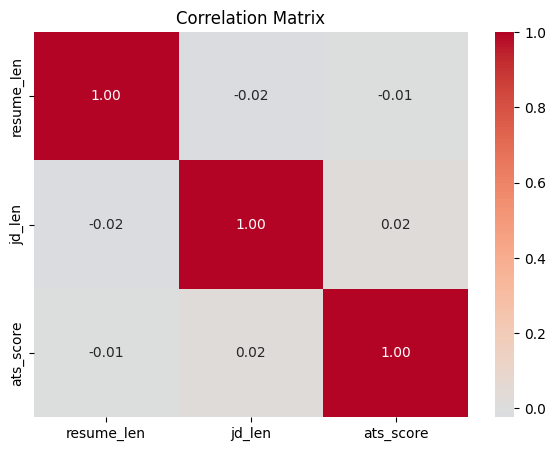

In [ ]:
# Step 23: summarize numeric relationships in one correlation heatmap
plt.figure(figsize=(7, 5))
corr = eda_df[['resume_len', 'jd_len', 'match_score']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix For Length Features And Score')
plt.show()

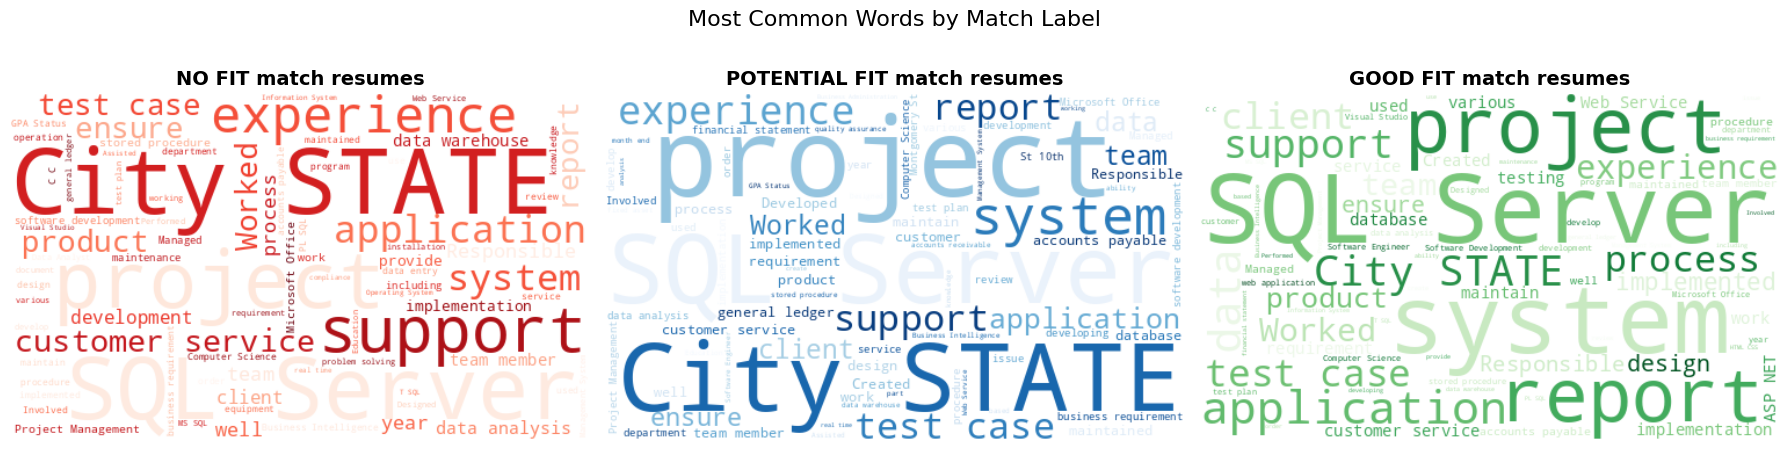

In [ ]:
# Step 24: show the most common resume keywords in each label bucket
# This is easier to interpret than a word cloud because every bar has an exact count.
def top_terms_for_label(frame, label, text_col='resume_text', top_n=10):
    subset = frame.loc[frame['match_label'] == label, text_col].dropna().astype(str)
    if subset.empty:
        return pd.Series(dtype='int64')

    vectorizer = CountVectorizer(stop_words='english', max_features=5000)
    matrix = vectorizer.fit_transform(subset)
    counts = np.asarray(matrix.sum(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    top_idx = counts.argsort()[-top_n:][::-1]
    return pd.Series(counts[top_idx], index=terms[top_idx])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, label, color in zip(axes, ['low', 'medium', 'high'], ['#d1495b', '#edae49', '#2a9d8f']):
    top_terms = top_terms_for_label(eda_df, label)
    sns.barplot(x=top_terms.values, y=top_terms.index, color=color, ax=ax)
    ax.set_title(f'Top Resume Terms: {label.title()}')
    ax.set_xlabel('Count')
    ax.set_ylabel('Term')

plt.tight_layout()
plt.show()

## EDA Takeaways And Transition To Training

What the EDA should tell you:
- label balance shows whether the model may become biased toward one class
- score distributions show how hard the separation problem is
- text length plots show whether very long or very short texts dominate
- keyword plots reveal common themes inside each match bucket

Important modeling decision:
We now move from EDA into pairwise embedding training. The model will learn that a resume and a job description with strong semantic alignment should produce a higher similarity score than unrelated pairs.

In [ ]:
# Step 25: build one compact summary table from the EDA features
eda_summary = (
    eda_df.groupby('match_label')
    .agg(
        rows=('match_score', 'size'),
        avg_score=('match_score', 'mean'),
        avg_resume_words=('resume_len', 'mean'),
        avg_jd_words=('jd_len', 'mean'),
    )
    .round(2)
    .reindex(['low', 'medium', 'high'])
)
display(eda_summary)

# Colab Training Pipeline

What is it?
This is the full Google Colab training workflow for your ATS resume-job matching task.

What does it do?
The pipeline installs packages, prepares clean resume-job pairs, creates fresh train, validation, and test splits, compares candidate backbones, fine-tunes the best model, validates the result, and saves reusable artifacts.

Why do we use it?
This structure turns your raw dataset into a repeatable training experiment that is easier to understand, debug, and reuse.

What is the output?
By the end of the pipeline you will have a fine-tuned model folder, prediction and metadata files, validation figures, and a reusable inference function for new resume-job pairs.

In [ ]:
# Colab package setup
!pip -q install -U sentence-transformers accelerate

In [ ]:
# Step 26A: import the libraries used in the training pipeline
import gc
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

from sentence_transformers import InputExample, SentenceTransformer, losses
from sentence_transformers.evaluation import EmbeddingSimilarityEvaluator

### Step 26B: Runtime Configuration

What is it?
This markdown introduces the runtime setup cell.

What does it do?
The next cell fixes the random seed, detects whether Colab is using GPU or CPU, and defines batch size, sequence length, and epoch count.

Why do we use it?
A stable configuration makes training reproducible and keeps the notebook safe for a T4 GPU.

What is the output?
You will see the device name, GPU name if available, and the main training settings printed clearly.

In [ ]:
# Step 26B: define reproducible training settings for Colab
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
TRAIN_BATCH_SIZE = 8 if DEVICE == 'cuda' else 4
ENCODE_BATCH_SIZE = 32 if DEVICE == 'cuda' else 16
MAX_SEQ_LENGTH = 320
EPOCHS = 4

sns.set_theme(style='whitegrid')

print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Train batch size: {TRAIN_BATCH_SIZE}')
print(f'Encode batch size: {ENCODE_BATCH_SIZE}')
print(f'Max sequence length: {MAX_SEQ_LENGTH}')
print(f'Epochs: {EPOCHS}')

In [ ]:
# Step 27A: define dataset paths and a safe loader
TRAIN_CSV_PATH = '/content/drive/MyDrive/Datasets/Resume_dataset/ATS_scoring_resume_dataset/train.csv'
VAL_CSV_PATH = '/content/drive/MyDrive/Datasets/Resume_dataset/ATS_scoring_resume_dataset/validation.csv'


def load_if_needed():
    global train_data, val_data

    if 'train_data' not in globals():
        train_data = pd.read_csv(TRAIN_CSV_PATH)
    if 'val_data' not in globals():
        val_data = pd.read_csv(VAL_CSV_PATH)

### Step 27B: Recover Resume And Job Description Columns

What is it?
This markdown explains the helper that reconstructs pair columns.

What does it do?
The next cell checks whether `resume_text` and `job_description` already exist. If not, it splits the raw `text` column on `SEP` and cleans whitespace.

Why do we use it?
The training model needs two separate inputs. This helper makes the notebook work on both raw and already-split datasets.

What is the output?
There is no big printed output. The result is a reusable function that returns a dataframe with clean pair columns.

In [ ]:
# Step 27B: create or recover pair columns from the dataset

def ensure_pair_columns(df):
    data = df.copy()

    if 'resume_text' not in data.columns:
        data['resume_text'] = pd.Series([pd.NA] * len(data), index=data.index, dtype='string')
    else:
        data['resume_text'] = data['resume_text'].astype('string')

    if 'job_description' not in data.columns:
        data['job_description'] = pd.Series([pd.NA] * len(data), index=data.index, dtype='string')
    else:
        data['job_description'] = data['job_description'].astype('string')

    if 'text' in data.columns:
        split_cols = data['text'].astype('string').str.split(r'(?i)\s*\bSEP\b\s*', n=1, expand=True)
        if split_cols.shape[1] == 2:
            data['resume_text'] = data['resume_text'].combine_first(split_cols[0].astype('string').str.strip())
            data['job_description'] = data['job_description'].combine_first(split_cols[1].astype('string').str.strip())

    data['resume_text'] = data['resume_text'].astype('string').str.strip()
    data['job_description'] = data['job_description'].astype('string').str.strip()
    data['job_description'] = data['job_description'].str.replace(
        r'^-\s*Share resume to.*?Job Title',
        'Job Title',
        regex=True,
    )
    return data

### Step 27C: Normalize Scores And Labels

What is it?
This explains the helper that standardizes the training target.

What does it do?
The next cell finds the score column, converts it to numeric form, rescales it into the `0 to 1` range, and creates a consistent low, medium, high label bucket.

Why do we use it?
Different datasets may store scores as `0 to 100` or `0 to 1`. A single normalized target is required for cosine-similarity training.

What is the output?
The output is a helper function that returns a dataframe with `match_score` and `match_label` ready for training.

In [ ]:
# Step 27C: normalize the numeric score and standardize label buckets

def normalize_scores_and_labels(df):
    data = df.copy()

    score_col = None
    for candidate in ['match_score', 'ats_score', 'score', 'label_score']:
        if candidate in data.columns:
            score_col = candidate
            break

    if score_col is None:
        raise ValueError('No score column found. Expected one of: match_score, ats_score, score, label_score.')

    data['match_score_raw'] = pd.to_numeric(data[score_col], errors='coerce')
    scale = 100.0 if data['match_score_raw'].dropna().max() > 1.0 else 1.0
    data['match_score'] = (data['match_score_raw'] / scale).clip(0.0, 1.0)

    if 'match_label' in data.columns:
        label_source = data['match_label'].astype('string').str.strip().str.lower()
    elif 'original_label' in data.columns:
        label_source = data['original_label'].astype('string').str.strip().str.lower()
    else:
        label_source = pd.Series([pd.NA] * len(data), index=data.index, dtype='string')

    label_map = {
        'no fit': 'low',
        'potential fit': 'medium',
        'good fit': 'high',
        'low': 'low',
        'medium': 'medium',
        'high': 'high',
    }
    mapped_labels = label_source.map(label_map)

    derived_labels = pd.Series([pd.NA] * len(data), index=data.index, dtype='string')
    derived_labels.loc[data['match_score'] < 0.40] = 'low'
    derived_labels.loc[data['match_score'].between(0.40, 0.70, inclusive='both')] = 'medium'
    derived_labels.loc[data['match_score'] > 0.70] = 'high'

    data['match_label'] = mapped_labels.combine_first(derived_labels)
    return data

### Step 27D: Clean The Dataset Before Splitting

What is it?
This markdown introduces the cleaning helper.

What does it do?
The next cell drops rows with missing text or missing score, removes empty resume and job-description strings, and removes duplicates.

Why do we use it?
Training quality depends on clean text pairs. Bad rows can confuse both the baseline comparison and the fine-tuning stage.

What is the output?
The helper prints how many rows were kept after cleaning and returns a clean dataframe.

In [ ]:
# Step 27D: define the cleaning helper used before train/validation/test splitting

def clean_dataset(df, source_name):
    data = ensure_pair_columns(df)
    data = normalize_scores_and_labels(data)
    data['source_name'] = source_name

    before = len(data)
    data = data.dropna(subset=['resume_text', 'job_description', 'match_score', 'match_label']).copy()
    data = data[(data['resume_text'].str.len() > 0) & (data['job_description'].str.len() > 0)].copy()

    if 'text' in data.columns:
        data = data.drop_duplicates(subset=['text'])
    else:
        data = data.drop_duplicates(subset=['resume_text', 'job_description', 'match_score'])

    print(f'{source_name}: kept {len(data):,} / {before:,} rows after cleaning')
    return data.reset_index(drop=True)

### Step 27E: Build Fresh Training Splits

What is it?
This is the execution step for the preprocessing helpers.

What does it do?
The next cell loads the dataset if needed, cleans train and validation data, merges them, shuffles the rows, and creates fresh train, validation, and test splits.

Why do we use it?
A clean split makes baseline comparison and fine-tuning fair. It also gives us a real held-out test set.

What is the output?
You will see row counts for each split, label balance for each split, and a preview of the final training format.

In [ ]:
# Step 27E: execute cleaning and create fresh train, validation, and test splits
load_if_needed()
train_clean = clean_dataset(train_data, 'train_csv')
val_clean = clean_dataset(val_data, 'validation_csv')

full_df = pd.concat([train_clean, val_clean], ignore_index=True)
full_df = full_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    full_df,
    test_size=0.20,
    random_state=SEED,
    stratify=full_df['match_label'],
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['match_label'],
)

print(f'Full dataset: {len(full_df):,}')
print(f'Train:        {len(train_df):,}')
print(f'Validation:   {len(val_df):,}')
print(f'Test:         {len(test_df):,}')

for split_name, split_df in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"{split_name} label distribution: {split_df['match_label'].value_counts(normalize=True).round(3).to_dict()}")

display(train_df[['resume_text', 'job_description', 'match_score', 'match_label']].head(2))

## Baseline Backbone Selection

What is it?
This section compares several pretrained embedding backbones before any fine-tuning.

What does it do?
It formats the text correctly for each model family, defines evaluation metrics, scores a validation sample, and ranks the candidate backbones.

Why do we use it?
Fine-tuning starts from a better point when the selected base model already understands resume-job similarity reasonably well.

What is the output?
You will get a table of candidate models with MAE, RMSE, Pearson, and Spearman, plus the name of the selected best backbone.

In [ ]:
# Step 28A: define candidate models and how each model should read the input text
CANDIDATE_MODELS = [
    'sentence-transformers/all-mpnet-base-v2',
    'BAAI/bge-base-en-v1.5',
    'intfloat/e5-base-v2',
]
SELECTION_SAMPLE_SIZE = min(len(val_df), 768)


def apply_model_text_format(model_name, texts, side):
    values = pd.Series(texts, dtype='string').fillna('').tolist()

    if model_name.startswith('intfloat/e5'):
        prefix = 'query: ' if side == 'job_description' else 'passage: '
        return [prefix + value for value in values]

    if model_name.startswith('BAAI/bge'):
        instruction = 'Represent this text for resume-job semantic matching: '
        return [instruction + value for value in values]

    return values

print('Candidate models:')
for model_name in CANDIDATE_MODELS:
    print('-', model_name)

### Step 28B: Metric Helpers

What is it?
This markdown introduces the helper functions for numeric evaluation.

What does it do?
The next cell defines Pearson, Spearman, MAE, and RMSE helpers that summarize how close predicted similarities are to the ground-truth ATS scores.

Why do we use it?
One metric is not enough. MAE and RMSE measure error size, while Pearson and Spearman measure ranking and correlation quality.

What is the output?
There is no large visual output here. The result is a set of reusable metric functions used in all later evaluation cells.

In [ ]:
# Step 28B: define reusable evaluation metrics

def safe_pearson(y_true, y_pred):
    try:
        result = pearsonr(y_true, y_pred)
        return float(getattr(result, 'statistic', result[0]))
    except Exception:
        return float('nan')


def safe_spearman(y_true, y_pred):
    try:
        result = spearmanr(y_true, y_pred)
        return float(getattr(result, 'correlation', result[0]))
    except Exception:
        return float('nan')


def regression_metrics(y_true, y_pred):
    return {
        'mae': float(mean_absolute_error(y_true, y_pred)),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'pearson': safe_pearson(y_true, y_pred),
        'spearman': safe_spearman(y_true, y_pred),
    }

### Step 28C: Prediction Helper

What is it?
This markdown explains the helper used to produce similarity scores from any model.

What does it do?
The next cell encodes resume text and job-description text, normalizes the embeddings, and computes cosine-style similarity with a dot product.

Why do we use it?
The same prediction logic is needed for baseline comparison, fine-tuned evaluation, and later inference.

What is the output?
The result is a reusable helper function that returns a score between `0` and `1` for each resume-job pair.

In [ ]:
# Step 28C: define how any model turns a resume-job pair into a similarity score

def predict_scores(model, frame, model_name):
    left_texts = apply_model_text_format(model_name, frame['resume_text'], 'resume_text')
    right_texts = apply_model_text_format(model_name, frame['job_description'], 'job_description')

    left_embeddings = model.encode(
        left_texts,
        batch_size=ENCODE_BATCH_SIZE,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )
    right_embeddings = model.encode(
        right_texts,
        batch_size=ENCODE_BATCH_SIZE,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=True,
    )

    predictions = (left_embeddings * right_embeddings).sum(axis=1)
    return np.clip(predictions, 0.0, 1.0)

### Step 28D: Run The Baseline Benchmark

What is it?
This markdown introduces the actual baseline comparison run.

What does it do?
The next cell samples the validation set, scores it with each candidate backbone, builds a ranking table, and chooses the best backbone automatically.

Why do we use it?
This gives a data-driven starting point instead of choosing a model by guesswork.

What is the output?
You will see a dataframe of model results and a printed line showing the selected best model.

In [ ]:
# Step 28D: benchmark the candidate backbones and choose the best starting model
selection_df = val_df.sample(n=SELECTION_SAMPLE_SIZE, random_state=SEED) if len(val_df) > SELECTION_SAMPLE_SIZE else val_df.copy()

baseline_rows = []
for model_name in CANDIDATE_MODELS:
    print(f'\nEvaluating base model: {model_name}')
    candidate_model = SentenceTransformer(model_name, device=DEVICE)
    candidate_model.max_seq_length = MAX_SEQ_LENGTH

    candidate_preds = predict_scores(candidate_model, selection_df, model_name)
    candidate_metrics = regression_metrics(selection_df['match_score'], candidate_preds)
    baseline_rows.append({'model_name': model_name, **candidate_metrics})

    del candidate_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

baseline_df = pd.DataFrame(baseline_rows).sort_values(['mae', 'rmse', 'spearman'], ascending=[True, True, False]).reset_index(drop=True)
display(baseline_df)

best_model_name = baseline_df.loc[0, 'model_name']
print(f'\nSelected backbone for fine-tuning: {best_model_name}')

## Fine-Tune The Best Backbone

What is it?
This section converts the cleaned dataset into the format expected by sentence-transformers and trains the selected model.

What does it do?
It creates output paths, builds `InputExample` pairs, prepares the dataloader and loss, and runs fine-tuning.

Why do we use it?
Fine-tuning moves the embedding space toward your ATS scoring task instead of relying only on general semantic similarity.

What is the output?
You will get a saved model directory, printed training settings, and a fine-tuned checkpoint that can be evaluated and reused later.

In [ ]:
# Step 29A: define where the fine-tuned model will be saved
OUTPUT_ROOT = '/content/drive/MyDrive/ATS_resume_matching_models' if os.path.exists('/content/drive/MyDrive') else 'models'
RUN_NAME = f"resume_matcher_{best_model_name.split('/')[-1]}"
MODEL_DIR = str(Path(OUTPUT_ROOT) / RUN_NAME)
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)

print(f'Model output directory: {MODEL_DIR}')

### Step 29B: Build Sentence Pair Training Examples

What is it?
This markdown explains how raw dataframe rows become training examples.

What does it do?
The next cell formats each resume and job description pair and wraps it into `InputExample` with the normalized match score.

Why do we use it?
Sentence-transformers training expects examples in this pair-plus-label format.

What is the output?
You will see the number of training and validation examples, plus a short preview of one example.

In [ ]:
# Step 29B: convert dataframe rows into sentence-transformers InputExample objects

def build_input_examples(frame, model_name):
    left_texts = apply_model_text_format(model_name, frame['resume_text'], 'resume_text')
    right_texts = apply_model_text_format(model_name, frame['job_description'], 'job_description')

    return [
        InputExample(texts=[left_text, right_text], label=float(score))
        for left_text, right_text, score in zip(left_texts, right_texts, frame['match_score'])
    ]


train_examples = build_input_examples(train_df, best_model_name)
val_examples = build_input_examples(val_df, best_model_name)

print(f'Train examples: {len(train_examples):,}')
print(f'Validation examples: {len(val_examples):,}')
print('\nExample pair preview:')
print(train_examples[0].texts[0][:200])
print('---')
print(train_examples[0].texts[1][:200])
print('Label:', train_examples[0].label)

### Step 29C: Prepare The Training Objects

What is it?
This markdown introduces the model objects used during optimization.

What does it do?
The next cell loads the selected backbone, creates the dataloader, builds the cosine-similarity loss, creates the validation evaluator, and computes warmup steps.

Why do we use it?
These objects define how the model sees batches, how learning is measured, and how progress is checked after each epoch.

What is the output?
You will see the training setup summary: model name, output directory, number of pairs, epochs, and warmup steps.

In [ ]:
# Step 29C: create the model, loss, evaluator, and warmup schedule
train_model = SentenceTransformer(best_model_name, device=DEVICE)
train_model.max_seq_length = MAX_SEQ_LENGTH

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=TRAIN_BATCH_SIZE)
train_loss = losses.CosineSimilarityLoss(train_model)
evaluator = EmbeddingSimilarityEvaluator.from_input_examples(val_examples, name='ats-val')

total_steps = len(train_dataloader) * EPOCHS
warmup_steps = max(1, int(total_steps * 0.10))

print(f'Training model:   {best_model_name}')
print(f'Output directory: {MODEL_DIR}')
print(f'Train pairs:      {len(train_examples):,}')
print(f'Validation pairs: {len(val_examples):,}')
print(f'Epochs:           {EPOCHS}')
print(f'Warmup steps:     {warmup_steps}')

### Step 29D: Run Fine-Tuning

What is it?
This is the actual optimization step.

What does it do?
The next cell trains the selected backbone on your ATS pairs, evaluates during training, and saves the best model checkpoint.

Why do we use it?
This is the step that adapts a general-purpose semantic model into a resume-job matching model.

What is the output?
You will see the progress bar, evaluation steps, and a final message when fine-tuning completes.

In [ ]:
# Step 29D: fine-tune the selected backbone on the ATS similarity task
train_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    evaluator=evaluator,
    epochs=EPOCHS,
    evaluation_steps=max(1, len(train_dataloader)),
    warmup_steps=warmup_steps,
    output_path=MODEL_DIR,
    save_best_model=True,
    use_amp=torch.cuda.is_available(),
    show_progress_bar=True,
)

print('\nFine-tuning complete.')

## Validate How The Model Works

What is it?
This section checks whether fine-tuning actually improved the resume-job matching model.

What does it do?
It scores the test set with both the base model and the fine-tuned model, compares metrics, and visualizes prediction behavior.

Why do we use it?
A fine-tuned model is only useful if it performs better on held-out data, not just on the training set.

What is the output?
You will see metric dictionaries, a comparison table, and multiple validation figures that explain model behavior.

In [ ]:
# Step 30A: load the base model and score the held-out test set
if 'train_model' in globals():
    del train_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

base_model = SentenceTransformer(best_model_name, device=DEVICE)
base_model.max_seq_length = MAX_SEQ_LENGTH
base_test_preds = predict_scores(base_model, test_df, best_model_name)
base_test_metrics = regression_metrics(test_df['match_score'], base_test_preds)
base_abs_error = np.abs(test_df['match_score'] - base_test_preds)

del base_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('Base model test metrics')
print(json.dumps(base_test_metrics, indent=2))

### Step 30B: Score Validation And Test With The Fine-Tuned Model

What is it?
This markdown explains the fine-tuned scoring step.

What does it do?
The next cell loads the saved fine-tuned model and computes predictions on both validation and test sets.

Why do we use it?
Validation scores help check training quality, while test scores show how the final model behaves on unseen data.

What is the output?
You will see validation and test metric dictionaries for the fine-tuned model.

In [ ]:
# Step 30B: load the fine-tuned model and score validation and test data
finetuned_model = SentenceTransformer(MODEL_DIR, device=DEVICE)
finetuned_model.max_seq_length = MAX_SEQ_LENGTH
finetuned_val_preds = predict_scores(finetuned_model, val_df, best_model_name)
finetuned_test_preds = predict_scores(finetuned_model, test_df, best_model_name)
finetuned_val_metrics = regression_metrics(val_df['match_score'], finetuned_val_preds)
finetuned_test_metrics = regression_metrics(test_df['match_score'], finetuned_test_preds)
finetuned_abs_error = np.abs(test_df['match_score'] - finetuned_test_preds)

print('Fine-tuned validation metrics')
print(json.dumps(finetuned_val_metrics, indent=2))
print('\nFine-tuned test metrics')
print(json.dumps(finetuned_test_metrics, indent=2))

### Step 30C: Compare Metrics In Table Form

What is it?
This markdown introduces the compact comparison summary.

What does it do?
The next cell combines base-model and fine-tuned-model metrics into one dataframe.

Why do we use it?
A single table makes it easy to compare error size and correlation quality side by side.

What is the output?
You will see a dataframe with one row for the base model and one row for the fine-tuned model.

In [ ]:
# Step 30C: build a side-by-side metric comparison table
comparison_df = pd.DataFrame([
    {'model': 'base', **base_test_metrics},
    {'model': 'fine_tuned', **finetuned_test_metrics},
])
display(comparison_df)

### Step 30D: Visual Validation Dashboard

What is it?
This markdown introduces the plots used to explain model behavior.

What does it do?
The next cell shows predicted-vs-actual scatter, absolute-error histograms, prediction distributions by label, and a metric comparison chart.

Why do we use it?
Plots show whether the fine-tuned model behaves sensibly, not just whether one metric improved slightly.

What is the output?
You will see a 2 by 2 dashboard of validation figures.

In [ ]:
# Step 30D: visualize prediction quality and model behavior on the test set
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
point_colors = test_df['match_label'].map({'low': '#d1495b', 'medium': '#edae49', 'high': '#2a9d8f'}).fillna('steelblue')

axes[0, 0].scatter(test_df['match_score'], finetuned_test_preds, c=point_colors, alpha=0.65)
axes[0, 0].plot([0, 1], [0, 1], 'k--')
axes[0, 0].set_title('Fine-Tuned Model: Predicted vs Actual')
axes[0, 0].set_xlabel('Ground Truth Score')
axes[0, 0].set_ylabel('Predicted Similarity')

sns.histplot(base_abs_error, bins=25, color='#6c757d', alpha=0.55, label='base', ax=axes[0, 1])
sns.histplot(finetuned_abs_error, bins=25, color='#2a9d8f', alpha=0.55, label='fine_tuned', ax=axes[0, 1])
axes[0, 1].set_title('Absolute Error Distribution')
axes[0, 1].set_xlabel('Absolute Error')
axes[0, 1].legend()

plot_df = test_df[['match_label']].copy()
plot_df['prediction'] = finetuned_test_preds
sns.boxplot(data=plot_df, x='match_label', y='prediction', order=['low', 'medium', 'high'],
            palette=['#d1495b', '#edae49', '#2a9d8f'], ax=axes[1, 0])
axes[1, 0].set_title('Fine-Tuned Predictions By Label')
axes[1, 0].set_xlabel('True Label Bucket')
axes[1, 0].set_ylabel('Predicted Similarity')

metric_plot = comparison_df.melt(id_vars='model', value_vars=['mae', 'rmse', 'pearson', 'spearman'],
                                 var_name='metric', value_name='value')
sns.barplot(data=metric_plot, x='metric', y='value', hue='model', ax=axes[1, 1])
axes[1, 1].set_title('Base vs Fine-Tuned Metric Comparison')
axes[1, 1].set_xlabel('Metric')
axes[1, 1].set_ylabel('Value')

plt.tight_layout()
plt.show()

## Save Artifacts And Test With Realistic Examples

What is it?
This final section packages the model outputs and demonstrates real-world usage.

What does it do?
It saves prediction files and metadata, defines an inference function, and scores a few manual resume-job examples.

Why do we use it?
A trained model is only useful if you can save it, reload it, and apply it to new candidate-job pairs.

What is the output?
You will get saved files on Drive plus a small manual-test table and figure showing high, medium, and low example scores.

In [ ]:
# Step 31A: save row-level predictions for later analysis
artifact_dir = Path(MODEL_DIR)
predictions_path = artifact_dir / 'test_predictions.csv'
metrics_path = artifact_dir / 'metrics.json'

test_results = test_df[['resume_text', 'job_description', 'match_score', 'match_label']].copy()
test_results['base_prediction'] = base_test_preds
test_results['finetuned_prediction'] = finetuned_test_preds
test_results['absolute_error'] = np.abs(test_results['match_score'] - test_results['finetuned_prediction'])
test_results.to_csv(predictions_path, index=False)

print(f'Saved predictions: {predictions_path}')

### Step 31B: Save Run Metadata

What is it?
This markdown explains the training-summary export.

What does it do?
The next cell collects the selected backbone, training settings, dataset sizes, and evaluation metrics into a JSON file.

Why do we use it?
Metadata makes experiments reproducible and helps you compare runs later.

What is the output?
You will see the saved metadata path and the saved model directory.

In [ ]:
# Step 31B: save the experiment configuration and summary metrics
run_metadata = {
    'selected_backbone': best_model_name,
    'max_seq_length': MAX_SEQ_LENGTH,
    'train_batch_size': TRAIN_BATCH_SIZE,
    'encode_batch_size': ENCODE_BATCH_SIZE,
    'epochs': EPOCHS,
    'train_rows': int(len(train_df)),
    'val_rows': int(len(val_df)),
    'test_rows': int(len(test_df)),
    'base_test_metrics': base_test_metrics,
    'finetuned_val_metrics': finetuned_val_metrics,
    'finetuned_test_metrics': finetuned_test_metrics,
}
with open(metrics_path, 'w') as output_file:
    json.dump(run_metadata, output_file, indent=2)

print(f'Saved model directory: {artifact_dir}')
print(f'Saved metrics: {metrics_path}')

### Step 31C: Create A Reusable Inference Function

What is it?
This markdown introduces the function used for future ATS scoring.

What does it do?
The next cell defines a function that takes one resume and one job description and returns a similarity score from the fine-tuned model.

Why do we use it?
This is the simplest reusable interface for real prediction after training is finished.

What is the output?
The output is a Python function named `score_resume_against_jd` that you can call on any new pair.

In [ ]:
# Step 31C: define the reusable scoring function for new resume-job pairs

def score_resume_against_jd(resume_text, job_description, model=finetuned_model, model_name=best_model_name):
    left = apply_model_text_format(model_name, [resume_text], 'resume_text')
    right = apply_model_text_format(model_name, [job_description], 'job_description')

    left_embedding = model.encode(left, convert_to_numpy=True, normalize_embeddings=True)
    right_embedding = model.encode(right, convert_to_numpy=True, normalize_embeddings=True)
    score = float(np.clip((left_embedding * right_embedding).sum(axis=1)[0], 0.0, 1.0))
    return score

### Step 31D: Run Manual Business-Style Test Cases

What is it?
This markdown introduces a few human-readable test examples.

What does it do?
The next cell scores handcrafted high, medium, and low match examples, builds a small result table, and plots the predicted scores.

Why do we use it?
These examples help you judge whether the model behaves in a way that matches business intuition, not just metric averages.

What is the output?
You will see a dataframe of expected versus predicted match buckets and a bar chart of the predicted scores.

In [ ]:
# Step 31D: run a few realistic manual test cases against the fine-tuned model
demo_cases = [
    {
        'expected': 'high',
        'resume': 'Python backend developer with FastAPI, Django, PostgreSQL, Docker, and AWS deployment experience.',
        'job_description': 'Hiring a Python backend engineer with Django or FastAPI, SQL, Docker, and cloud deployment skills.',
    },
    {
        'expected': 'medium',
        'resume': 'Frontend developer with React, TypeScript, UI testing, and some Node.js API experience.',
        'job_description': 'Looking for a full-stack engineer with React on the frontend and Python backend experience.',
    },
    {
        'expected': 'low',
        'resume': 'Executive chef with experience in menu design, kitchen operations, food cost control, and fine dining.',
        'job_description': 'Need a machine learning engineer with Python, deep learning, NLP, and model deployment skills.',
    },
]

manual_test_rows = []
for case in demo_cases:
    score = score_resume_against_jd(case['resume'], case['job_description'])
    predicted_bucket = 'high' if score > 0.70 else 'medium' if score >= 0.40 else 'low'
    manual_test_rows.append({
        'expected_bucket': case['expected'],
        'predicted_bucket': predicted_bucket,
        'predicted_score': round(score, 4),
    })

manual_test_df = pd.DataFrame(manual_test_rows)
display(manual_test_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=manual_test_df, x='expected_bucket', y='predicted_score', palette=['#d1495b', '#edae49', '#2a9d8f'])
plt.title('Manual Example Scores')
plt.xlabel('Expected Bucket')
plt.ylabel('Predicted Similarity')
plt.ylim(0, 1)
plt.show()